In [28]:
import mesa
import matplotlib.pyplot as plt

# --- Scale constants (the physical meaning of the abstract grid) ---
CELL_SIZE_M = 0.5        # each cell is 0.5m x 0.5m (one person's footprint)
SECONDS_PER_STEP = 0.5   # one occupant moves one cell (0.5m) per step at ~1 m/s

# --- Floor plan dimensions (in cells) ---
GRID_WIDTH = 20
GRID_HEIGHT = 15

# --- Exit locations (list of (x, y) cells), from your sketch ---
# Exit 1: bottom-right.  Exit 2: top-left.
EXITS = [(16, 0), (17, 0), (2, 14), (3, 14)]

In [29]:
class OccupantAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        # State: "moving" until they reach an exit, then "escaped".
        self.state = "moving"
        # NFPA 101 pre-movement time: how many steps this occupant waits
        # before starting to move. Uniform random 0-60 steps (0-30 sec).
        # randint(a, b) returns a whole number between a and b inclusive.
        self.reaction_delay = self.random.randint(0, 60)

        # A counter tracking how long this occupant has existed (in steps).
        self.steps_waited = 0

    # Helper: straight-line (Euclidean) distance from a point to a cell.
    def distance_to(self, cell):
        x1, y1 = self.pos          # my current position
        x2, y2 = cell              # the target cell
        # Pythagoras: sqrt(dx^2 + dy^2). ** 0.5 is square root.
        return ((x1 - x2) ** 2 + (y1 - y2) ** 2) ** 0.5

    def step(self):
        # Already out? Do nothing.
        if self.state == "escaped":
            return

        # NFPA pre-movement: if still in the reaction-delay window,
        # count one more step waited and do nothing else this tick.
        if self.steps_waited < self.reaction_delay:
            self.steps_waited += 1
            return  # don't move yet — still reacting


        # 1. Pick my nearest exit. min(...) with key=distance_to finds the
        #    exit cell with the smallest distance from me.
        target = min(self.model.exits, key=self.distance_to)

        # 2. Look at my 8 neighboring cells (Moore, no diagonals excluded).
        neighbors = self.model.grid.get_neighborhood(
            self.pos, moore=True, include_center=False
        )

        # 3. Keep only neighbors that aren't walls (wall-collision enforcement).
        valid = [c for c in neighbors if c not in self.model.walls]

        # 4. From valid cells, step to the one closest to my target exit.
        #    (A tiny "greedy" pathfinder: always move toward the goal.)
        if valid:
            best = min(valid, key=lambda c: self._dist(c, target))
            self.model.grid.move_agent(self, best)

        # 5. If I'm now on an exit cell, I've escaped — and record which exit.
        if self.pos in self.model.exits:
            self.state = "escaped"
            self.model.exit_usage[self.pos] += 1   # tally this exit
            self.model.grid.remove_agent(self)

    # Helper: distance between any two cells (used in step 4).
    def _dist(self, a, b):
        return ((a[0] - b[0]) ** 2 + (a[1] - b[1]) ** 2) ** 0.5

In [30]:
def count_escaped(model):
    # Model reporter: how many have escaped so far.
    return model.escaped_count

class BuildingModel(mesa.Model):
    def __init__(self, n_occupants, seed=None):
        super().__init__(seed=seed)
        self.grid = mesa.space.MultiGrid(GRID_WIDTH, GRID_HEIGHT, torus=False)
        self.exits = set(EXITS)          # set = fast membership checks
        self.escaped_count = 0
        self.exit_usage = {exit_cell: 0 for exit_cell in EXITS}

        # Build perimeter walls: every edge cell EXCEPT exit gaps.
        self.walls = set()
        for x in range(GRID_WIDTH):
            for y in range(GRID_HEIGHT):
                on_edge = (x == 0 or x == GRID_WIDTH - 1
                           or y == 0 or y == GRID_HEIGHT - 1)
                if on_edge and (x, y) not in self.exits:
                    self.walls.add((x, y))

        # Scatter occupants on random INTERIOR (non-wall, non-exit) cells.
        agents = OccupantAgent.create_agents(model=self, n=n_occupants)
        for agent in agents:
            while True:
                x = self.random.randrange(GRID_WIDTH)
                y = self.random.randrange(GRID_HEIGHT)
                if (x, y) not in self.walls and (x, y) not in self.exits:
                    self.grid.place_agent(agent, (x, y))
                    break

        self.datacollector = mesa.DataCollector(
            model_reporters={"Escaped": count_escaped}
        )

    def step(self):
        self.datacollector.collect(self)
        self.agents.shuffle_do("step")
        # Recount escapees each tick (agents removed from grid still in self.agents).
        self.escaped_count = sum(
            1 for a in self.agents if a.state == "escaped"
        )

In [31]:
model = BuildingModel(50)
for i in range(100):
    model.step()
print(f"Escaped: {model.escaped_count} of 50")

Escaped: 50 of 50


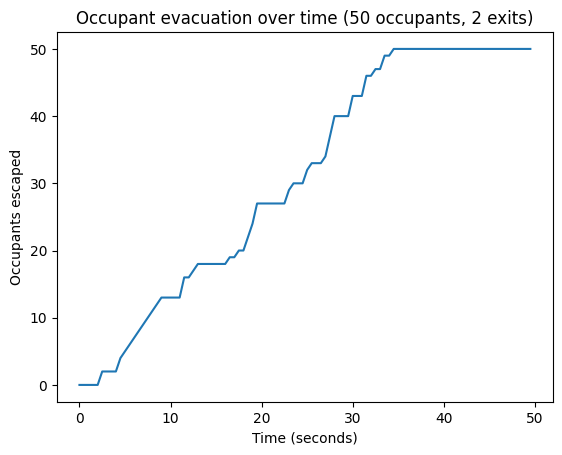

In [32]:
# Pull the model-level time series: how many had escaped at each step.
data = model.datacollector.get_model_vars_dataframe()

# Convert the step index into real seconds using our scale constant,
# so the x-axis is meaningful (seconds), not abstract steps.
data.index = data.index * SECONDS_PER_STEP

# Plot escaped-over-time.
data.plot(
    title="Occupant evacuation over time (50 occupants, 2 exits)",
    xlabel="Time (seconds)",
    ylabel="Occupants escaped",
    legend=False,
)
plt.show()

In [33]:
model = BuildingModel(50)
for i in range(100):
    model.step()

print(f"Escaped: {model.escaped_count} of 50")
print("Exit usage by cell:")
for cell, count in model.exit_usage.items():
    print(f"  Exit cell {cell}: {count} occupants")

Escaped: 50 of 50
Exit usage by cell:
  Exit cell (16, 0): 12 occupants
  Exit cell (17, 0): 10 occupants
  Exit cell (2, 14): 12 occupants
  Exit cell (3, 14): 16 occupants
